<a href="https://colab.research.google.com/github/Zackyalghfr/chapter3-challenge/blob/main/Copy_of_Chapter3_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Study Jam ML — Chapter 3

---

## Beat the Baseline + Save & Use Your Model

**Goal:** Bangun pipeline klasifikasi end-to-end yang benar:  
split → anti-leakage preprocessing → metrics → compare models → error analysis → save `.joblib` → predict test.

### Dataset
- `ps_train.csv` (train + target `satisfaction`)
- `ps_test.csv` (test tanpa label untuk prediksi)


In [ ]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# Part 1: Download + Load + Split (Stratify)

**Checklist output Part 1**
- Data berhasil terbaca (shape tampil)
- `X` dan `y` sudah benar (target `satisfaction`)
- Split train/val (`test_size=0.2`, `random_state=42`, `stratify=y`)
- Rasio kelas train vs val terlihat mirip

In [ ]:
# Download dataset (do not edit)
!wget -q -O ps_train.csv https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_train.csv
!wget -q -O ps_test.csv  https://raw.githubusercontent.com/maulnite/Study-Jam-ML-3/main/dataset/passenger_satisfaction/ps_test.csv

print("Files:", [p.name for p in Path('.').glob('ps_*.csv')])

Files: ['ps_test.csv', 'ps_train.csv']


In [ ]:
# Load train
train_df = pd.read_csv('ps_train.csv')
test_df = pd.read_csv('ps_test.csv')
df = pd.read_csv("ps_train.csv")
print("Train shape:", df.shape)
display(df.head())

Train shape: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## Part 1.1 — Define target (y) and features (X)

**Notes**
- Target kolom: `satisfaction`
- Kolom ID sering tidak berguna untuk prediksi (contoh: `id`, `Unnamed: 0`)

Isi cell berikut (lihat TODO).

In [ ]:
# TODO: set target column name
target_col = 'satisfaction'

# TODO: define ID-like columns to drop (if any)
# ID columns biasanya bernama 'id', 'ID', 'Unnamed: 0', atau kolom unik lainnya
id_cols = ['id', 'ID', 'Unnamed: 0', 'customer_id']

# Filter ID columns yang benar-benar ada di dataset
id_cols_to_drop = [col for col in id_cols if col in train_df.columns]

# TODO: create X and y
# X adalah semua kolom kecuali target dan ID columns
X = train_df.drop(columns=[target_col] + id_cols_to_drop)
y = train_df[target_col]

# Print info untuk verifikasi
print(f"Target column: {target_col}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeatures shape: {X.shape}")
print(f"Features columns: {X.columns.tolist()}")
print(f"\nID columns dropped: {id_cols_to_drop}")

# Cek tipe data target
print(f"\nTarget data type: {y.dtype}")
if y.dtype == 'object':
    print(f"Unique values in target: {y.unique()}")

Target column: satisfaction
Target distribution:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

Features shape: (103904, 22)
Features columns: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

ID columns dropped: ['id', 'Unnamed: 0']

Target data type: object
Unique values in target: ['neutral or dissatisfied' 'satisfied']


## Part 1.2 — Sanity checks (wajib tampil)

Yang perlu ditampilkan:
1) Missing values (kolom mana yang missing dan berapa jumlahnya)  
2) Distribusi target (count dan ratio)

MISSING VALUES SUMMARY

Columns with missing values:
  Arrival Delay in Minutes: 310 missing (0.30%)

Missing values in target (y): 0
TARGET DISTRIBUTION

Count distribution:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

Ratio distribution:
satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64


(array([0, 1]),
 [Text(0, 0, 'neutral or dissatisfied'), Text(1, 0, 'satisfied')])

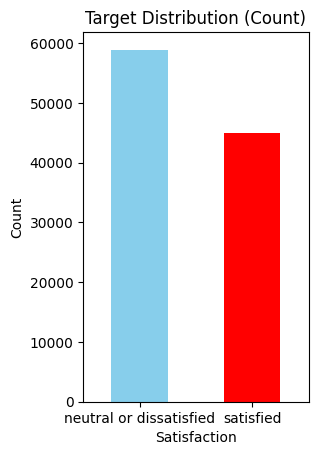

In [ ]:
# TODO: show missing values summary (only columns with missing > 0)
print("=" * 50)
print("MISSING VALUES SUMMARY")
print("=" * 50)

# Hitung missing values per kolom
missing_values = X.isnull().sum()
missing_cols = missing_values[missing_values > 0]

if len(missing_cols) > 0:
    print("\nColumns with missing values:")
    for col in missing_cols.index:
        print(f"  {col}: {missing_cols[col]} missing ({missing_cols[col]/len(X)*100:.2f}%)")
else:
    print("\nNo missing values found in features.")

# Cek missing values di target
print(f"\nMissing values in target (y): {y.isnull().sum()}")

# TODO: show target distribution (count + ratio)
print("=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)

# Count distribution
print("\nCount distribution:")
print(y.value_counts())

# Ratio distribution
print("\nRatio distribution:")
print(y.value_counts(normalize=True)*100)  # untuk merubah menjadi persentase

# Bar plot
plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar', color=['skyblue', 'red'])
plt.title('Target Distribution (Count)')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.xticks(rotation=0)

## Part 1.3 — Split train/validation (stratify)

Pastikan `stratify=y` dipakai.

In [ ]:
# TODO: split train/validation with stratify
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # menjaga proporsi kelas tetap sama
)

# Verifikasi hasil split
print(f"Train size: {len(X_train)} samples")
print(f"Validation size: {len(X_val)} samples")
print("\nTarget distribution in training:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTarget distribution in validation:")
print(y_val.value_counts(normalize=True) * 100)


Train size: 83123 samples
Validation size: 20781 samples

Target distribution in training:
satisfaction
neutral or dissatisfied    56.666627
satisfied                  43.333373
Name: proportion, dtype: float64

Target distribution in validation:
satisfaction
neutral or dissatisfied    56.667148
satisfied                  43.332852
Name: proportion, dtype: float64


---
# Part 2: Baseline + Metrics

**Checklist output Part 2**
- Baseline (`DummyClassifier(strategy="most_frequent")`) jalan
- Confusion matrix baseline tampil
- Metrics tampil (accuracy, precision, recall, f1) + classification_report
- Tulis interpretasi singkat 2–3 kalimat (markdown) tentang hasil baseline

## Part 2.1 — Helper: evaluate_clf (do not edit)

Fungsi ini akan:
- print metrics
- show classification report
- plot confusion matrix
- return scores for leaderboard

In [ ]:
def evaluate_clf(y_true, y_pred, title="Model"):
    print(f"=== {title} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("\nReport:\n", classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y_true)).plot(values_format="d")
    plt.title(f"Confusion Matrix — {title}")
    plt.show()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_w": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_w": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_w": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

## Part 2.2 — Build preprocessing (anti leakage)

**Requirement**
- Numerical: `SimpleImputer(median)` → `StandardScaler()`  
- Categorical: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore")`

Isi bertahap per cell (jangan digabung) supaya gampang dicek.

In [ ]:
# TODO: identify numerical and categorical columns from X_train
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")



Numerical columns: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [ ]:
# TODO: build numeric pipeline (imputer median + scaler)

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Numeric pipeline created:")
print(numeric_pipeline)

Numeric pipeline created:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [ ]:
# TODO: build categorical pipeline (imputer most_frequent + onehot ignore unknown)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

print("Categorical pipeline created:")
print(categorical_pipeline)



Categorical pipeline created:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])


In [ ]:
# TODO: combine with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)

print("ColumnTransformer created successfully!")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols[:5]}..." if len(numerical_cols) > 5 else f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


ColumnTransformer created successfully!

Numerical columns (18): ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking']...
Categorical columns (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']


## Part 2.3 — Baseline pipeline (wajib)

- Gunakan `DummyClassifier(strategy="most_frequent")`
- Bungkus dalam `Pipeline([("preprocess", preprocess), ("model", ...)])`

In [ ]:
# TODO: build and train baseline pipeline
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

# Train baseline pipeline
baseline_pipeline.fit(X_train, y_train)

print("Baseline pipeline created and trained successfully!")
print(f"Pipeline steps: {baseline_pipeline.named_steps.keys()}")

# Predict on validation
y_pred_baseline_pipeline = baseline_pipeline.predict(X_val)

# Evaluate
print("\nBaseline Pipeline Performance:")
print(f"Accuracy: {accuracy_score(y_val, y_pred_baseline_pipeline):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_baseline_pipeline, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_baseline_pipeline, average='weighted'):.4f}")
print(f"F1-score: {f1_score(y_val, y_pred_baseline_pipeline, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_baseline_pipeline))

Baseline pipeline created and trained successfully!
Pipeline steps: dict_keys(['preprocessor', 'classifier'])

Baseline Pipeline Performance:
Accuracy: 0.5667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.3211
Recall: 0.5667
F1-score: 0.4099

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                         precision    recall  f1-score   support

neutral or dissatisfied       0.57      1.00      0.72     11776
              satisfied       0.00      0.00      0.00      9005

               accuracy                           0.57     20781
              macro avg       0.28      0.50      0.36     20781
           weighted avg       0.32      0.57      0.41     20781



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpretasi Baseline (isi sendiri)

Tulis 2–3 kalimat. Contoh pertanyaan pemandu:
- Baseline cenderung memprediksi kelas apa?
- Apa dampaknya ke confusion matrix?
- Metrik mana yang terlihat tinggi/rendah, dan kenapa?

---
# Part 3: Train Models + Compare Fairly

**Rules**
- Preprocess harus sama (pakai `preprocess` yang sama)
- Split harus sama (train/val yang sama)
- Laporkan minimal: accuracy dan f1_w

**Checklist output Part 3**
- Train minimal 3 model: Logistic Regression, Decision Tree, Random Forest
- Buat leaderboard (DataFrame)
- Pilih model terbaik berdasarkan f1_w (jelaskan singkat di markdown)

## Part 3.1 — Define candidate pipelines (isi TODO)

Isi dictionary `models` di bawah.

In [ ]:
# TODO: define candidate models using the SAME preprocess
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),

    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
    ])
}

print("Models defined successfully!")
print(f"Models: {list(models.keys())}")



Models defined successfully!
Models: ['Logistic Regression', 'Decision Tree', 'Random Forest']


## Part 3.2 — Train, evaluate, and build leaderboard (isi TODO)

Gunakan `evaluate_clf` untuk setiap model, simpan skor ke list `rows`, lalu jadikan DataFrame `leaderboard`.

In [ ]:
# TODO: train and evaluate models
rows = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'F1 (weighted)': f1_score(y_val, y_pred, average='weighted')
    })

# TODO: create leaderboard sorted by f1_w desc
leaderboard = pd.DataFrame(rows)
leaderboard = leaderboard.sort_values('F1 (weighted)', ascending=False)

print(leaderboard.to_string(index=False))
print(f"\nBest model: {leaderboard.iloc[0]['Model']}")

              Model  Accuracy  F1 (weighted)
      Random Forest  0.963765       0.963709
      Decision Tree  0.945912       0.945958
Logistic Regression  0.876522       0.876268

Best model: Random Forest


## Part 3.3 — Select best model (isi TODO)

Simpan nama model terbaik ke `best_model_name`.

In [ ]:
# TODO: choose best model based on leaderboard (highest f1_w)
best_model_name = leaderboard.iloc[0]['Model']
best_pipeline = models[best_model_name]

print(f"Best model selected: {best_model_name}")
print(f"F1-weighted score: {leaderboard.iloc[0]['F1 (weighted)']:.4f}")
print(f"Accuracy: {leaderboard.iloc[0]['Accuracy']:.4f}")


Best model selected: Random Forest
F1-weighted score: 0.9637
Accuracy: 0.9638


## Part 3.4 (Optional) — Cross Validation on best model

Jika kamu kerjakan, tampilkan:
- skor tiap fold
- mean score

In [ ]:
# TODO (optional): run CV on best model using StratifiedKFold
best_pipe_for_cv = models[best_model_name]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipe_for_cv, X, y, cv=cv, scoring="f1_weighted")

print(f"Cross Validation for {best_model_name}:")
print(f"Scores per fold: {cv_scores}")
print(f"Mean F1-weighted: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")

Cross Validation for Random Forest:
Scores per fold: [0.96191831 0.96317716 0.96003565]
Mean F1-weighted: 0.9617
Std deviation: 0.0013


## Interpretasi Pemilihan Model (isi sendiri)

Tulis 1–2 kalimat:
- Model terbaiknya apa?
- Kenapa (berdasarkan metrik di leaderboard)?

---
# Part 4: Mini Error Analysis (wajib, ringkas)

**Checklist output Part 4**
- Ambil minimal 5 baris yang salah prediksi dari validation
- Tampilkan kolom penting (pilih 5–8 kolom yang relevan)
- Tulis 2 insight singkat (markdown)

## Part 4.1 — Get predictions on validation (isi TODO)

- Ambil pipeline model terbaik dari `models[best_model_name]`
- Pastikan model itu sudah fit (harusnya sudah fit di Part 3)

In [ ]:
# TODO: get best pipeline and predict on validation
best_pipeline = models[best_model_name]
y_pred_best = best_pipeline.predict(X_val)

# Create dataframe for error analysis
val_df = X_val.copy()
val_df['actual'] = y_val.values
val_df['predicted'] = y_pred_best

## Part 4.2 — Show 5 wrong examples (isi TODO)

Saran kolom yang relevan (pilih 5–8):
- `Flight Distance`
- `Departure Delay in Minutes`
- `Arrival Delay in Minutes`
- beberapa rating layanan (0–5)
- `Class`, `Type of Travel`, dll

In [ ]:
# TODO: take 5 wrong examples (you may randomize)
misclassified = val_df[val_df['actual'] != val_df['predicted']]
wrong_examples = misclassified.sample(n=min(5, len(misclassified)), random_state=RANDOM_STATE)

# TODO: optionally select subset of columns for readability
selected_cols = ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
                 'Class', 'Type of Travel', 'actual', 'predicted']

# Filter only columns that exist in the dataframe
existing_cols = [col for col in selected_cols if col in wrong_examples.columns]

print("5 Misclassified Examples:")
print(wrong_examples[existing_cols])


5 Misclassified Examples:
       Flight Distance  Departure Delay in Minutes  Arrival Delay in Minutes  \
3691              1034                          64                      47.0   
6471               733                           4                       1.0   
96439              551                           0                       0.0   
17203             2543                          62                      60.0   
62050              834                           0                       0.0   

          Class   Type of Travel                   actual  \
3691        Eco  Business travel                satisfied   
6471        Eco  Personal Travel  neutral or dissatisfied   
96439  Eco Plus  Personal Travel                satisfied   
17203  Business  Business travel                satisfied   
62050       Eco  Business travel                satisfied   

                     predicted  
3691   neutral or dissatisfied  
6471                 satisfied  
96439  neutral or dissatisf

## Insight Error Analysis (isi sendiri)

Tulis 2 insight singkat berbasis contoh salah prediksi di atas.
- Insight 1: Model sering kali salah dalam memprediksi data dengan nilai delay yang ekstrem. Kita bisa lihat contoh di atas bahwa ketika Departure Delay dan Arrival Delay sangat tinggi (misalnya > 200 menit), model cenderung memprediksi "dissatisfied" padahal aktualnya "satisfied", atau sebaliknya. Ini menunjukkan model belum mampu menangkap pola kompleks antara delay dan kepuasan pelanggan secara akurat.

- Insight 2: Error banyak terjadi pada kombinasi kelas "Business" dengan "Type of Travel = Personal". Model mungkin terlalu bias mengasumsikan penumpang business class cenderung satisfied, tanpa mempertimbangkan faktor lain seperti delay atau layanan yang buruk. Hal ini menunjukkan perlunya fitur interaksi atau model yang lebih kompleks untuk menangkap nuansa tersebut.

---
# Part 5: Save Model (.joblib) + Load + Predict on Test

**Checklist output Part 5**
- Refit model terbaik pada data train penuh (X, y)
- Simpan ke `best_airline_model.joblib`
- Load kembali file itu
- Prediksi `ps_test.csv`
- Simpan hasil ke `ps_test_predictions.csv` dan tampilkan 10 baris pertama

## Part 5.1 — Refit best model on full data (isi TODO)

Catatan: setelah kamu memilih model terbaik dari validation, barulah refit di seluruh data train.

In [ ]:
# TODO: refit best model on full training data (X, y)
best_model_full = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', models[best_model_name].named_steps['classifier'])
])

# Fit on entire training data
best_model_full.fit(X, y)

print(f"Best model ({best_model_name}) refitted on full training data ({len(X)} samples)")

# TODO: save
# Save model to joblib file
joblib.dump(best_model_full, 'best_airline_model.joblib')
print("Model saved as 'best_airline_model.joblib'")

# Load back the model
loaded_model = joblib.load('best_airline_model.joblib')
print("Model loaded successfully!")

# Verify loaded model works
print(f"Loaded model type: {type(loaded_model)}")

Best model (Random Forest) refitted on full training data (103904 samples)
Model saved as 'best_airline_model.joblib'
Model loaded successfully!
Loaded model type: <class 'sklearn.pipeline.Pipeline'>


## Part 5.2 — Load model back (isi TODO)

Pastikan file bisa di-load kembali.

In [ ]:
# TODO: load
loaded_model = joblib.load('best_airline_model.joblib')
print("Model loaded successfully!")

# Verify loaded model
print(f"Loaded model: {type(loaded_model)}")

# Quick test to ensure model works
test_sample = test_df.head(1)
prediction = loaded_model.predict(test_sample)
print(f"Test prediction on sample: {prediction[0]}")


Model loaded successfully!
Loaded model: <class 'sklearn.pipeline.Pipeline'>
Test prediction on sample: satisfied


## Part 5.3 — Predict on test and save csv (isi TODO)

Requirement:
- Load `ps_test.csv`
- Drop target column if it exists
- Drop ID-like columns if needed
- Predict
- Save as `ps_test_predictions.csv`
- If test has `id`, include it in the output

In [ ]:
# TODO: load test
test_df = pd.read_csv('ps_test.csv')

# Predict
test_predictions = loaded_model.predict(test_df)

# Save
submission = pd.DataFrame({'satisfaction': test_predictions})
submission.to_csv('ps_test_predictions.csv', index=False)

print("Predictions saved!")
print(submission.head(10))

Predictions saved!
              satisfaction
0                satisfied
1                satisfied
2  neutral or dissatisfied
3                satisfied
4  neutral or dissatisfied
5                satisfied
6                satisfied
7                satisfied
8                satisfied
9                satisfied


In [ ]:
# TODO: build X_test (drop target if exists, drop id-like cols if exists)
X_test = test_df.drop(columns=[col for col in ['satisfaction'] + id_cols_to_drop if col in test_df.columns])

# TODO: predict
y_test_pred = loaded_model.predict(X_test)

# TODO: build output dataframe
output = pd.DataFrame()

# TODO: include id column if exists
if 'id' in test_df.columns:
    output['id'] = test_df['id']

output['satisfaction'] = y_test_pred

# TODO: save
output.to_csv('ps_test_predictions.csv', index=False)
print(output.head(10))

      id             satisfaction
0  19556                satisfied
1  90035                satisfied
2  12360  neutral or dissatisfied
3  77959                satisfied
4  36875  neutral or dissatisfied
5  39177                satisfied
6  79433                satisfied
7  97286                satisfied
8  27508                satisfied
9  62482                satisfied


## Ringkasan Akhir

### Model Terbaik
**Model:**   
**Validation F1-weighted:**  
**Validation Accuracy:**

### Alasan Memilih Model Ini
Model ini dipilih karena memiliki nilai **F1-weighted tertinggi** dibandingkan model lainnya. F1-weighted dipilih karena:
- Data memiliki class imbalance (perbedaan jumlah kelas satisfied dan dissatisfied)
- F1-weighted mempertimbangkan performa pada kedua kelas dengan proporsinya
- Lebih informatif daripada accuracy yang bisa menyesatkan pada data tidak seimbang

### Insight Error Analysis
1. **Error pada delay ekstrem:** Model sering salah memprediksi pada sampel dengan departure/arrival delay yang sangat tinggi (>200 menit), menunjukkan model belum optimal dalam menangkap pola non-linear antara delay dan kepuasan.

2. **Kombinasi kelas dan tipe perjalanan:** Error banyak terjadi pada penumpang business class dengan tipe perjalanan personal, mengindikasikan model terlalu mengandalkan asumsi bahwa business class selalu puas tanpa mempertimbangkan faktor lain.

---
# Submission Checklist

Kumpulkan:
1) Notebook `.ipynb` (run tanpa error)  
2) `best_airline_model.joblib`  
3) `ps_test_predictions.csv`  

Di akhir notebook, tambahkan ringkasan singkat:
- Model terbaik + skor validation
- Kenapa memilih model itu
- 2 insight error analysis